## Inference With The Trained Model

In [1]:
import time
import numpy as np
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt

In [2]:
model_path= "models/best_MediTrack_IESTI05.pt"
task = "detect" 
verbose = True

In [3]:
model = YOLO(model_path, task, verbose)

In [4]:
# Open an image using PIL
source = Image.open("dataset/background_cefalexina_cloridratoDeAmbroxol_sanyD/image_20251019-231628.jpg")

In [5]:
# Run inference on the source
results = model.predict(source, save=False, imgsz=640, conf=0.5, iou=0.3)
result = results[0]
result


0: 480x640 2 cefalexinas, 2 sany_Ds, 7229.8ms
Speed: 201.0ms preprocess, 7229.8ms inference, 170.2ms postprocess per image at shape (1, 3, 480, 640)


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'cefalexina', 1: 'cloridrato_de_ambroxol', 2: 'medicine', 3: 'sany_D'}
obb: None
orig_img: array([[[ 8,  7,  3],
        [13, 12,  8],
        [13, 12,  8],
        ...,
        [ 3, 11, 10],
        [ 1,  9,  9],
        [ 0,  3,  3]],

       [[ 7,  5,  4],
        [ 6,  7,  5],
        [ 9,  7,  6],
        ...,
        [ 0,  8,  5],
        [ 0,  6,  5],
        [ 0,  4,  3]],

       [[ 5,  5,  5],
        [ 1,  3,  3],
        [ 3,  3,  3],
        ...,
        [ 4, 11,  6],
        [ 1,  8,  5],
        [ 2,  9,  6]],

       ...,

       [[ 4,  2,  8],
        [ 1,  0,  4],
        [ 3,  2,  4],
        ...,
        [ 6,  7,  5],
        [ 6,  7,  5],
        [ 6,  7,  5]],

       [[ 4,  3,  7],
        [ 3,  2,  6],
        [ 1,  0,  2],
        ...,
        [ 4,  5,  3],
        [ 3,  4,  2],
        [ 3,  4,  2]],

       [[ 6,  5

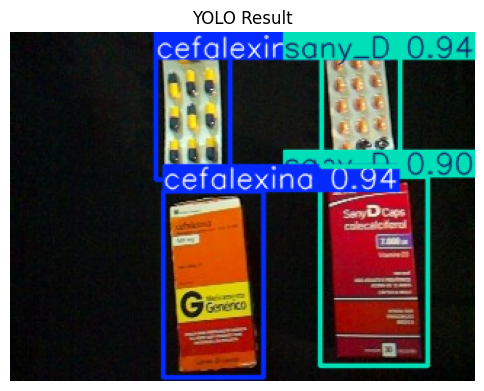

In [6]:
im_bgr = result.plot()
img = Image.fromarray(im_bgr[..., ::-1])

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Result")
plt.show()

### Creating a function

In [7]:
def infer_yolo(source, conf=0.5, iou=0.3):
    results = model.predict(source, save=False, imgsz=640, conf=conf, iou=iou)
    result = results[0]

    im_bgr = result.plot()
    img = Image.fromarray(im_bgr[..., ::-1])

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # This turns off the axis numbers
    plt.title("YOLO Result")
    plt.show()

In [8]:
!ls dataset/background_cefalexina_cloridratoDeAmbroxol_sanyD

image_20251019-231333.jpg  image_20251019-232846.jpg  image_20251020-000832.jpg
image_20251019-231421.jpg  image_20251019-233032.jpg  image_20251020-000841.jpg
image_20251019-231423.jpg  image_20251019-233058.jpg  image_20251020-000849.jpg
image_20251019-231429.jpg  image_20251019-233101.jpg  image_20251020-000854.jpg
image_20251019-231448.jpg  image_20251019-233126.jpg  image_20251020-000917.jpg
image_20251019-231449.jpg  image_20251019-233150.jpg  image_20251020-000936.jpg
image_20251019-231457.jpg  image_20251019-233203.jpg  image_20251020-000940.jpg
image_20251019-231507.jpg  image_20251019-233419.jpg  image_20251020-000946.jpg
image_20251019-231545.jpg  image_20251019-233539.jpg  image_20251020-000951.jpg
image_20251019-231555.jpg  image_20251019-233553.jpg  image_20251020-001146.jpg
image_20251019-231624.jpg  image_20251019-233601.jpg  image_20251020-001149.jpg
image_20251019-231628.jpg  image_20251019-233632.jpg  image_20251020-001156.jpg
image_20251019-231642.jpg  image_2025101


image 1/1 /home/admin/MediTrack_IESTI05/YOLO/OBJ_DETC/dataset/background_cefalexina_cloridratoDeAmbroxol_sanyD/image_20251020-000618.jpg: 480x640 1 cefalexina, 1 cloridrato_de_ambroxol, 1 sany_D, 2696.0ms
Speed: 26.6ms preprocess, 2696.0ms inference, 8.2ms postprocess per image at shape (1, 3, 480, 640)


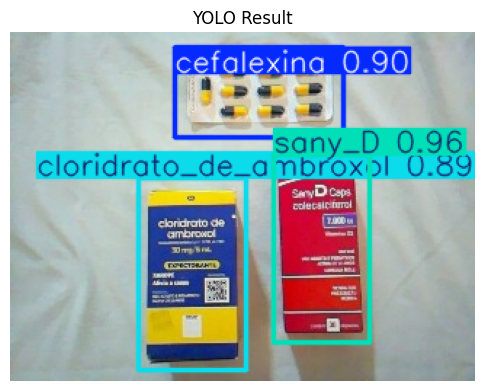

In [9]:
infer_yolo("dataset/background_cefalexina_cloridratoDeAmbroxol_sanyD/image_20251020-000618.jpg")


image 1/1 /home/admin/MediTrack_IESTI05/YOLO/OBJ_DETC/dataset/background_cefalexina_cloridratoDeAmbroxol_sanyD/image_20251019-231721.jpg: 480x640 1 cefalexina, 1 cloridrato_de_ambroxol, 2705.1ms
Speed: 24.0ms preprocess, 2705.1ms inference, 7.1ms postprocess per image at shape (1, 3, 480, 640)


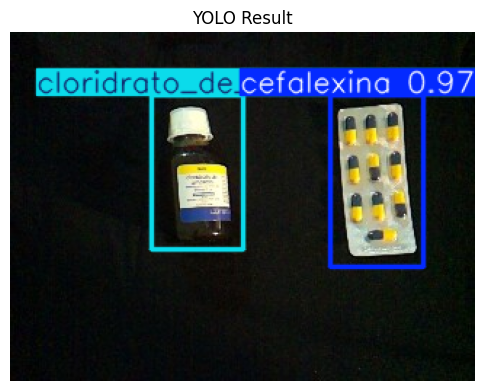

In [10]:
infer_yolo("dataset/background_cefalexina_cloridratoDeAmbroxol_sanyD/image_20251019-231721.jpg")

### Exporting the model 

In [11]:
from picamera2 import Picamera2

In [16]:
def capture_image(image_path):
    
  # Initialize camera
  picam2 = Picamera2() # default is index 0

  # Configure the camera
  config = picam2.create_still_configuration(main={"size": (320, 320)})
  picam2.configure(config)
  picam2.start()

  # Wait for the camera to warm up
  time.sleep(5)

  # Capture image
  picam2.capture_file(image_path)
  print("Image captured: "+image_path)

  # Stop camera
  picam2.stop()
  picam2.close()

In [13]:
img_path = './images/cam_img_yolo_test.jpg'
model_path = "models/best_MediTrack_IESTI05.pt"
task = "detect" 
verbose = False

In [14]:
model = YOLO(model_path, task, verbose)

[0:14:10.266830100] [960]  INFO Camera camera_manager.cpp:326 libcamera v0.5.1+100-e53bdf1f
[0:14:10.329585061] [977]  WARN RPiSdn sdn.cpp:40 Using legacy SDN tuning - please consider moving SDN inside rpi.denoise
[0:14:10.334888124] [977]  INFO RPI vc4.cpp:440 Registered camera /base/soc/i2c0mux/i2c@1/ov5647@36 to Unicam device /dev/media2 and ISP device /dev/media0
[0:14:10.334999104] [977]  INFO RPI pipeline_base.cpp:1107 Using configuration file '/usr/share/libcamera/pipeline/rpi/vc4/rpi_apps.yaml'
[0:14:10.359616934] [960]  INFO Camera camera.cpp:1205 configuring streams: (0) 320x320-BGR888/sRGB (1) 640x480-SGBRG10_CSI2P/RAW
[0:14:10.360395978] [977]  INFO RPI vc4.cpp:615 Sensor: /base/soc/i2c0mux/i2c@1/ov5647@36 - Selected sensor format: 640x480-SGBRG10_1X10 - Selected unicam format: 640x480-pGAA


Image captured: ./images/cam_img_yolo_test.jpg

image 1/1 /home/admin/MediTrack_IESTI05/YOLO/OBJ_DETC/images/cam_img_yolo_test.jpg: 640x640 1 cloridrato_de_ambroxol, 3631.7ms
Speed: 41.5ms preprocess, 3631.7ms inference, 6.2ms postprocess per image at shape (1, 3, 640, 640)


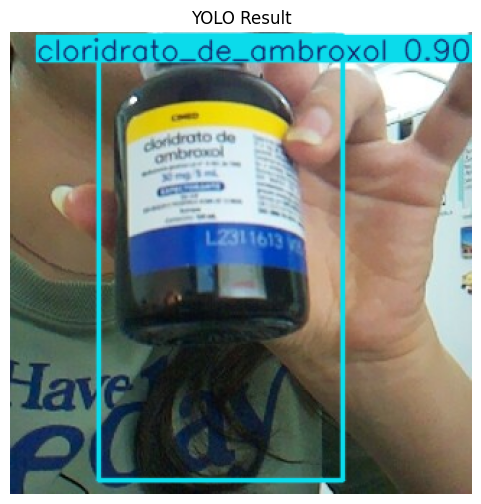

In [19]:
capture_image(img_path)
infer_yolo("images/cam_img_yolo_test.jpg")

In [2]:
!yolo export model="models/best_MediTrack_IESTI05.pt" format=ncnn 

Ultralytics 8.3.204 🚀 Python-3.11.2 torch-2.8.0+cpu CPU (aarch64)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'models/best_MediTrack_IESTI05.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (5.2 MB)

TorchScript: starting export with torch 2.8.0+cpu...
TorchScript: export success ✅ 47.7s, saved as 'models/best_MediTrack_IESTI05.torchscript' (10.4 MB)

NCNN: starting export with NCNN 1.0.20250916...
NCNN: running '/home/admin/yolo/lib/python3.11/site-packages/ultralytics/pnnx models/best_MediTrack_IESTI05.torchscript ncnnparam=models/best_MediTrack_IESTI05_ncnn_model/model.ncnn.param ncnnbin=models/best_MediTrack_IESTI05_ncnn_model/model.ncnn.bin ncnnpy=models/best_MediTrack_IESTI05_ncnn_model/model_ncnn.py pnnxparam=models/best_MediTrack_IESTI05_ncnn_model/model.pnnx.param pnnxbin=models/best_MediTrack_IESTI05_ncnn_model/model.pnnx.bin pnnxpy=models/best_MediTrack_IESTI05_ncnn_model/model_pnnx.py 

In [3]:
!ls ./models

best_MediTrack_IESTI05_ncnn_model  best_MediTrack_IESTI05.torchscript
best_MediTrack_IESTI05.pt


In [5]:
model_path= "models/best_MediTrack_IESTI05_ncnn_model"
task = "detect" 
verbose = True

In [6]:
# Load the converted ncnn model with a customized dataset
model = YOLO(model_path, task, verbose)

In [ ]:
infer_yolo("dataset/background_cefalexina_cloridratoDeAmbroxol_sanyD/image_20251019-231721.jpg")

Loading models/best_MediTrack_IESTI05_ncnn_model for NCNN inference...

